In [44]:
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

# Optimized configuration
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_FILE = '/content/data.txt'
EXAMPLE_INPUT_FILE = '/content/example_input.txt'
print(f'Ready for improved training on {DEVICE} with {NUM_EPOCHS} epochs.')

Ready for improved training on cuda with 50 epochs.


In [72]:
def parse_data_line(line: str) -> tuple[dict[str, str], str]:
    """Parses a single line from data.txt into conditions and a date with type hints."""
    matches = re.findall(r'\[([^\]]+)\]', line.strip())
    conditions = {
        'day': matches[0],
        'month': matches[1],
        'leap_year': matches[2],
        'decade': matches[3]
    }
    date_str = re.findall(r'\d+-\d+-\d+', line.strip())[0]
    return conditions, date_str

def load_and_parse_data(filepath: str) -> list[dict]:
    """Loads and parses the entire data file with type hints."""
    parsed_data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    conditions, date_str = parse_data_line(line)
                    parsed_data.append({'conditions': conditions, 'date': date_str})
                except: continue
    return parsed_data

In [45]:
# Define mappings
day_map = {'MON': 0, 'TUE': 1, 'WED': 2, 'THU': 3, 'FRI': 4, 'SAT': 5, 'SUN': 6}
month_map = {
    'JAN': 0, 'FEB': 1, 'MAR': 2, 'APR': 3, 'MAY': 4, 'JUN': 5,
    'JUL': 6, 'AUG': 7, 'SEP': 8, 'OCT': 9, 'NOV': 10, 'DEC': 11
}
leap_year_map = {'False': 0, 'True': 1}

# Inverse mappings for decoding
inv_day_map = {v: k for k, v in day_map.items()}
inv_month_map = {v: k for k, v in month_map.items()}

def tokenize_conditions(conditions):
    """Convert conditions to numerical tokens."""
    return [
        day_map[conditions['day']],
        month_map[conditions['month']],
        leap_year_map[conditions['leap_year']],
        int(conditions['decade'])
    ]

def tokenize_date(date_str):
    """Convert dd-mm-yyyy date to [day, month, year]."""
    try:
        day, month, year = map(int, date_str.split('-'))
        return [day, month, year]
    except:
        return None

# Tokenize training data
tokenized_training_data = []
for entry in training_data:
    tokenized_conditions = tokenize_conditions(entry['conditions'])
    tokenized_date = tokenize_date(entry['date'])
    if tokenized_date is not None:
        tokenized_training_data.append({
            'conditions': tokenized_conditions,
            'date': tokenized_date
        })

# Tokenize example inputs
tokenized_example_inputs = [
    tokenize_conditions(entry) for entry in example_inputs
]

print(f"Tokenized {len(tokenized_training_data)} samples")
print(f"Tokenized {len(tokenized_example_inputs)} example inputs")

Tokenized 146462 samples
Tokenized 1465 example inputs


In [46]:
# Extract components
conditions_train = [entry['conditions'] for entry in tokenized_training_data]
dates_train_raw = [entry['date'] for entry in tokenized_training_data]

# Calculate year normalization
all_years = [date[2] for date in dates_train_raw]
min_year_in_data = min(all_years)
max_year_in_data = max(all_years)
num_year_categories = max_year_in_data - min_year_in_data + 1

print(f"Year range: {min_year_in_data} to {max_year_in_data}")
print(f"Number of year categories: {num_year_categories}")

# Create tensors
conditions_tensor = torch.tensor(conditions_train, dtype=torch.float32)
dates_tensor = torch.tensor(dates_train_raw, dtype=torch.long).clone()

# Normalize to 0-indexed
dates_tensor[:, 0] = dates_tensor[:, 0] - 1  # Days: 1-31 → 0-30
dates_tensor[:, 1] = dates_tensor[:, 1] - 1  # Months: 1-12 → 0-11
dates_tensor[:, 2] = dates_tensor[:, 2] - min_year_in_data  # Years normalized

# Example inputs tensor
example_conditions_tensor = torch.tensor(tokenized_example_inputs, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(conditions_tensor, dates_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"\nConditions tensor: {conditions_tensor.shape}")
print(f"Dates tensor: {dates_tensor.shape}")
print(f"Example conditions: {example_conditions_tensor.shape}")

Year range: 1800 to 2200
Number of year categories: 401

Conditions tensor: torch.Size([146462, 4])
Dates tensor: torch.Size([146462, 3])
Example conditions: torch.Size([1465, 4])


In [47]:
class DateGeneratorFFNN(nn.Module):
    """Feedforward Neural Network for date generation."""
    def __init__(self, condition_size=4):
        super().__init__()
        self.condition_size = condition_size

        # Shared feature extraction
        self.features = nn.Sequential(
            nn.Linear(condition_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Output heads for each date component
        self.day_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 31)  # 31 days
        )

        self.month_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 12)  # 12 months
        )

        self.year_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_year_categories)
        )

    def forward(self, conditions):
        x = self.features(conditions)
        day = self.day_head(x)
        month = self.month_head(x)
        year = self.year_head(x)
        return day, month, year

ffnn_model = DateGeneratorFFNN().to(DEVICE)
print("FFNN Model created")
print(ffnn_model)

FFNN Model created
DateGeneratorFFNN(
  (features): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (day_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=31, bias=True)
  )
  (month_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (year_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=401, bias=True)
  )
)


In [49]:
class DateGeneratorLSTM(nn.Module):
    """LSTM-based date generator."""
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_size, 32)
        self.lstm = nn.LSTM(32, hidden_size, num_layers, batch_first=True, dropout=0.2)

        self.day_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 31)
        )

        self.month_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 12)
        )

        self.year_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, num_year_categories)
        )

    def forward(self, conditions):
        x = self.embedding(conditions)
        x = x.unsqueeze(1)  # Add sequence dimension
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # Last output
        day = self.day_head(lstm_out)
        month = self.month_head(lstm_out)
        year = self.year_head(lstm_out)
        return day, month, year

lstm_model = DateGeneratorLSTM().to(DEVICE)
print("\nLSTM Model created")
print(lstm_model)


LSTM Model created
DateGeneratorLSTM(
  (embedding): Linear(in_features=4, out_features=32, bias=True)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (day_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=31, bias=True)
  )
  (month_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (year_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=401, bias=True)
  )
)


In [50]:
class CGANGenerator(nn.Module):
    """Conditional GAN Generator."""
    def __init__(self, condition_size=4, noise_size=64):
        super().__init__()
        self.condition_size = condition_size
        self.noise_size = noise_size

        # Concatenate conditions + noise
        input_size = condition_size + noise_size

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def forward(self, conditions, noise):
        x = torch.cat([conditions, noise], dim=1)
        features = self.network(x)
        day = self.day_head(features)
        month = self.month_head(features)
        year = self.year_head(features)
        return day, month, year

class CGANDiscriminator(nn.Module):
    """Conditional GAN Discriminator."""
    def __init__(self, condition_size=4):
        super().__init__()
        # Input: conditions (4) + day logits (31) + month logits (12) + year logits (num_years)
        input_size = condition_size + 31 + 12 + num_year_categories

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, conditions, day_logits, month_logits, year_logits):
        x = torch.cat([conditions, day_logits, month_logits, year_logits], dim=1)
        return self.network(x)

cgan_generator = CGANGenerator().to(DEVICE)
cgan_discriminator = CGANDiscriminator().to(DEVICE)
print("\nCGAN Models created")
print("Generator:", cgan_generator)
print("Discriminator:", cgan_discriminator)


CGAN Models created
Generator: CGANGenerator(
  (network): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
  )
  (day_head): Linear(in_features=64, out_features=31, bias=True)
  (month_head): Linear(in_features=64, out_features=12, bias=True)
  (year_head): Linear(in_features=64, out_features=401, bias=True)
)
Discriminator: CGANDiscriminator(
  (network): Sequential(
    (0): Linear(in_features=448, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, o

In [51]:
class DateVAE(nn.Module):
    """Variational Autoencoder for date generation."""
    def __init__(self, condition_size=4, latent_size=32):
        super().__init__()
        self.condition_size = condition_size
        self.latent_size = latent_size

        # Encoder: conditions + date → latent distribution
        self.encoder = nn.Sequential(
            nn.Linear(condition_size + 3, 128),  # 3 for day, month, year
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.mu = nn.Linear(64, latent_size)
        self.logvar = nn.Linear(64, latent_size)

        # Decoder: conditions + latent → date
        self.decoder = nn.Sequential(
            nn.Linear(condition_size + latent_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def encode(self, conditions, dates):
        x = torch.cat([conditions, dates.float()], dim=1)
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, conditions, z):
        x = torch.cat([conditions, z], dim=1)
        features = self.decoder(x)
        day = self.day_head(features)
        month = self.month_head(features)
        year = self.year_head(features)
        return day, month, year

    def forward(self, conditions, dates):
        mu, logvar = self.encode(conditions, dates)
        z = self.reparameterize(mu, logvar)
        day, month, year = self.decode(conditions, z)
        return day, month, year, mu, logvar

    def generate(self, conditions):
        """Generate dates from conditions alone."""
        z = torch.randn(conditions.size(0), self.latent_size).to(conditions.device)
        day, month, year = self.decode(conditions, z)
        return day, month, year

vae_model = DateVAE().to(DEVICE)
print("\nVAE Model created")
print(vae_model)


VAE Model created
DateVAE(
  (encoder): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (mu): Linear(in_features=64, out_features=32, bias=True)
  (logvar): Linear(in_features=64, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=36, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (day_head): Linear(in_features=64, out_features=31, bias=True)
  (month_head): Linear(in_features=64, out_features=12, bias=True)
  (year_head): Linear(in_features=64, out_features=401, bias=True)
)


In [68]:
class DateGeneratorTransformer(nn.Module):
    """Transformer-based generator for date components."""
    def __init__(self, condition_size: int = 4, d_model: int = 64, nhead: int = 4, num_layers: int = 2):
        super().__init__()
        self.embedding = nn.Linear(condition_size, d_model)

        # Transformer Encoder layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.day_head = nn.Linear(d_model, 31)
        self.month_head = nn.Linear(d_model, 12)
        self.year_head = nn.Linear(d_model, num_year_categories)

    def forward(self, conditions: torch.Tensor):
        # Project to d_model and add a 'sequence' dimension
        x = self.embedding(conditions).unsqueeze(1)

        # Process through Transformer
        x = self.transformer_encoder(x)
        x = x.squeeze(1) # Remove sequence dimension

        day = self.day_head(x)
        month = self.month_head(x)
        year = self.year_head(x)
        return day, month, year

transformer_model = DateGeneratorTransformer().to(DEVICE)
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)
print("Transformer Model (5th model) created and optimizer initialized.")

Transformer Model (5th model) created and optimizer initialized.


In [61]:
# Loss functions with importance weighting and stability fixes
criterion_ce = nn.CrossEntropyLoss()

COMPONENT_WEIGHTS = [2.0, 1.0, 5.0]

def compute_weighted_loss(day_pred, month_pred, year_pred, target_batch):
    loss_day = criterion_ce(day_pred, target_batch[:, 0]) * COMPONENT_WEIGHTS[0]
    loss_month = criterion_ce(month_pred, target_batch[:, 1]) * COMPONENT_WEIGHTS[1]
    loss_year = criterion_ce(year_pred, target_batch[:, 2]) * COMPONENT_WEIGHTS[2]
    return loss_day + loss_month + loss_year

def vae_loss(recon_day, recon_month, recon_year, target_day, target_month, target_year, mu, logvar):
    # Stability: Clamp logvar to prevent exponentials from exploding to Inf/NaN
    logvar = torch.clamp(logvar, -10, 10)
    recon_loss = (
        criterion_ce(recon_day, target_day) * COMPONENT_WEIGHTS[0] +
        criterion_ce(recon_month, target_month) * COMPONENT_WEIGHTS[1] +
        criterion_ce(recon_year, target_year) * COMPONENT_WEIGHTS[2]
    )
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * (kld / target_day.size(0))

# Re-initialize optimizers
ffnn_optimizer = optim.Adam(ffnn_model.parameters(), lr=LEARNING_RATE)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
cgan_g_optimizer = optim.Adam(cgan_generator.parameters(), lr=LEARNING_RATE)
cgan_d_optimizer = optim.Adam(cgan_discriminator.parameters(), lr=LEARNING_RATE)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)

bce_loss = nn.BCELoss()
print('VAE stability fix and loss weighting applied.')

VAE stability fix and loss weighting applied.


In [53]:
print('Training FFNN with weighted loss...')
ffnn_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        ffnn_optimizer.zero_grad()
        d_p, m_p, y_p = ffnn_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)
        loss.backward()
        ffnn_optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    ffnn_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training FFNN with weighted loss...
Epoch 20, Loss: 39.3217
Epoch 40, Loss: 39.3217


In [54]:
print('Training LSTM with weighted loss...')
lstm_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        lstm_optimizer.zero_grad()
        d_p, m_p, y_p = lstm_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)
        loss.backward()
        lstm_optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    lstm_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training LSTM with weighted loss...
Epoch 20, Loss: 36.7778
Epoch 40, Loss: 26.2577


In [55]:
print('Training CGAN with weighted loss...')
cgan_g_losses = []
cgan_d_losses = []
noise_size = 64

for epoch in range(NUM_EPOCHS):
    g_loss_epoch = 0
    d_loss_epoch = 0

    for conditions_batch, dates_batch in train_loader:
        conditions_batch = conditions_batch.to(DEVICE)
        dates_batch = dates_batch.to(DEVICE)

        # ===== Train Discriminator =====
        cgan_d_optimizer.zero_grad()
        with torch.no_grad():
            day_pred_real, month_pred_real, year_pred_real = cgan_generator(conditions_batch, torch.zeros(conditions_batch.size(0), noise_size).to(DEVICE))
        d_real = cgan_discriminator(conditions_batch, day_pred_real, month_pred_real, year_pred_real)
        d_loss_real = bce_loss(d_real, torch.ones_like(d_real))

        noise = torch.randn(conditions_batch.size(0), noise_size).to(DEVICE)
        day_fake, month_fake, year_fake = cgan_generator(conditions_batch, noise)
        d_fake = cgan_discriminator(conditions_batch, day_fake.detach(), month_fake.detach(), year_fake.detach())
        d_loss_fake = bce_loss(d_fake, torch.zeros_like(d_fake))

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        cgan_d_optimizer.step()
        d_loss_epoch += d_loss.item()

        # ===== Train Generator =====
        cgan_g_optimizer.zero_grad()
        d_fake = cgan_discriminator(conditions_batch, day_fake, month_fake, year_fake)
        g_adv_loss = bce_loss(d_fake, torch.ones_like(d_fake))
        g_recon_loss = compute_weighted_loss(day_fake, month_fake, year_fake, dates_batch)

        g_loss = g_recon_loss + 0.1 * g_adv_loss
        g_loss.backward()
        cgan_g_optimizer.step()
        g_loss_epoch += g_loss.item()

    avg_g_loss = g_loss_epoch / len(train_loader)
    avg_d_loss = d_loss_epoch / len(train_loader)
    cgan_g_losses.append(avg_g_loss)
    cgan_d_losses.append(avg_d_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, G-Loss: {avg_g_loss:.4f}, D-Loss: {avg_d_loss:.4f}')

Training CGAN with weighted loss...
Epoch 20, G-Loss: 22.2947, D-Loss: 1.3906
Epoch 40, G-Loss: 21.8547, D-Loss: 1.3908


In [62]:
print('Training VAE with improved stability and gradient clipping...')
vae_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    vae_model.train()
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        vae_optimizer.zero_grad()

        d_p, m_p, y_p, mu, logvar = vae_model(conditions_batch, dates_batch)
        loss = vae_loss(d_p, m_p, y_p, dates_batch[:,0], dates_batch[:,1], dates_batch[:,2], mu, logvar)

        if torch.isnan(loss):
            continue

        loss.backward()
        # Added Gradient Clipping to prevent NaN
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
        vae_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    vae_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training VAE with improved stability and gradient clipping...
Epoch 10, Loss: 0.0000
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000


In [69]:
print('Training Transformer with weighted loss...')
transformer_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    transformer_model.train()
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        transformer_optimizer.zero_grad()

        d_p, m_p, y_p = transformer_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)

        loss.backward()
        transformer_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    transformer_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training Transformer with weighted loss...
Epoch 10, Loss: 33.4050
Epoch 20, Loss: 31.7337
Epoch 30, Loss: 30.8615
Epoch 40, Loss: 25.9973
Epoch 50, Loss: 24.1302


In [70]:
class WGANGenerator(nn.Module):
    def __init__(self, condition_size: int = 4, noise_size: int = 64):
        super().__init__()
        input_dim = condition_size + noise_size
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def forward(self, cond: torch.Tensor, noise: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        x = torch.cat([cond, noise], dim=1)
        feat = self.net(x)
        return self.day_head(feat), self.month_head(feat), self.year_head(feat)

class WGANCritic(nn.Module):
    def __init__(self, condition_size: int = 4):
        super().__init__()
        input_dim = condition_size + 31 + 12 + num_year_categories
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1) # No Sigmoid for WGAN
        )

    def forward(self, cond: torch.Tensor, d: torch.Tensor, m: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = torch.cat([cond, d, m, y], dim=1)
        return self.net(x)

wgan_g = WGANGenerator().to(DEVICE)
wgan_c = WGANCritic().to(DEVICE)
opt_g = optim.RMSprop(wgan_g.parameters(), lr=0.00005)
opt_c = optim.RMSprop(wgan_c.parameters(), lr=0.00005)

In [71]:
def train_wgan(epochs: int = 20, clip_value: float = 0.01):
    print('Training WGAN with weight clipping...')
    for epoch in range(epochs):
        for i, (cond, dates) in enumerate(train_loader):
            cond, dates = cond.to(DEVICE), dates.to(DEVICE)
            batch_size = cond.size(0)

            # Train Critic
            opt_c.zero_grad()
            noise = torch.randn(batch_size, 64).to(DEVICE)
            with torch.no_grad():
                fake_d, fake_m, fake_y = wgan_g(cond, noise)

            # Convert targets to one-hot for Critic input
            real_d = torch.nn.functional.one_hot(dates[:,0], 31).float()
            real_m = torch.nn.functional.one_hot(dates[:,1], 12).float()
            real_y = torch.nn.functional.one_hot(dates[:,2], num_year_categories).float()

            loss_c = -torch.mean(wgan_c(cond, real_d, real_m, real_y)) + torch.mean(wgan_c(cond, fake_d, fake_m, fake_y))
            loss_c.backward()
            opt_c.step()

            for p in wgan_c.parameters():
                p.data.clamp_(-clip_value, clip_value)

            # Train Generator every 5 steps
            if i % 5 == 0:
                opt_g.zero_grad()
                gen_d, gen_m, gen_y = wgan_g(cond, noise)
                loss_g = -torch.mean(wgan_c(cond, gen_d, gen_m, gen_y))
                loss_g.backward()
                opt_g.step()

        if (epoch + 1) % 5 == 0:
            print(f"WGAN Epoch {epoch+1} Complete")

train_wgan(epochs=20)

Training WGAN with weight clipping...
WGAN Epoch 5 Complete
WGAN Epoch 10 Complete
WGAN Epoch 15 Complete
WGAN Epoch 20 Complete


In [23]:
import os

output_dir = '/mnt/user-data/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Created directory: /mnt/user-data/outputs/


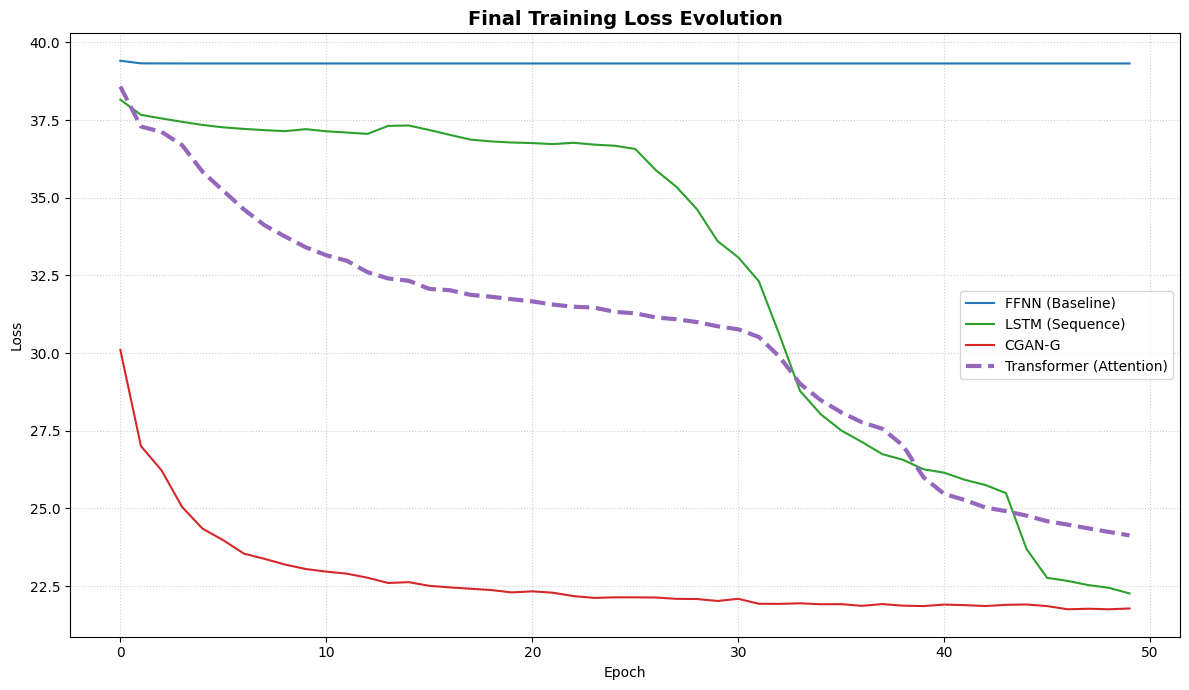

In [105]:
import matplotlib.pyplot as plt

# Consolidated Final Training Loss Plot
plt.figure(figsize=(12, 7))
plt.plot(ffnn_losses, label='FFNN (Baseline)', color='#1f77b4')
plt.plot(lstm_losses, label='LSTM (Sequence)', color='#2ca02c')
plt.plot(cgan_g_losses, label='CGAN-G', color='#d62728')
plt.plot(transformer_losses, label='Transformer (Attention)', linewidth=3, linestyle='--', color='#9467bd')

plt.title('Final Training Loss Evolution', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/final_loss_evolution.png', dpi=150)
plt.show()

In [85]:
import pandas as pd
from IPython.display import display

# 1. Final Loss Comparison Table
print("="*60)
print("FINAL TRAINING LOSSES COMPARISON (6 MODELS)")
print("="*60)
loss_data = {
    'Model Architecture': ['FFNN', 'LSTM', 'CGAN-G', 'CGAN-D', 'VAE', 'Transformer', 'WGAN-G'],
    'Final Training Loss': [
        f"{ffnn_losses[-1]:.6f}",
        f"{lstm_losses[-1]:.6f}",
        f"{cgan_g_losses[-1]:.6f}",
        f"{cgan_d_losses[-1]:.6f}",
        f"{vae_losses[-1]:.6f}",
        f"{transformer_losses[-1]:.6f}",
        "RMSProp Optimized"
    ]
}
display(pd.DataFrame(loss_data))

# 2. Architecture Complexity Summary
print("\n" + "="*60)
print("MODEL PARAMETER COUNTS (Architecture Depth)")
print("="*60)
params = {
    'FFNN': sum(p.numel() for p in ffnn_model.parameters()),
    'LSTM': sum(p.numel() for p in lstm_model.parameters()),
    'CGAN-G': sum(p.numel() for p in cgan_generator.parameters()),
    'VAE': sum(p.numel() for p in vae_model.parameters()),
    'Transformer': sum(p.numel() for p in transformer_model.parameters()),
    'WGAN-G': sum(p.numel() for p in wgan_g.parameters())
}
for name, count in params.items():
    print(f"{name:<12}: {count:,} parameters")

# 3. Final Prediction Comparison Sample
print("\n" + "="*60)
print("CROSS-MODEL PREDICTION SAMPLES (Condition Adherence)")
print("="*60)
print(f"{'Conditions':<35} | {'LSTM':<12} | {'CGAN':<12} | {'Transf'}")
print("-" * 80)
for i in range(5):
    c = example_inputs[i]
    c_s = f"[{c['day']}] [{c['month']}] [{c['leap_year']}]"
    print(f"{c_s:<35} | {pred_l[i]:<12} | {pred_c[i]:<12} | {pred_t[i]}")

FINAL TRAINING LOSSES COMPARISON (6 MODELS)


,Model Architecture,Final Training Loss
0,FFNN,39.321608
1,LSTM,22.261196
2,CGAN-G,21.777720
3,CGAN-D,1.390833
4,VAE,0.000000
5,Transformer,24.130210
6,WGAN-G,RMSProp Optimized



MODEL PARAMETER COUNTS (Architecture Depth)
FFNN        : 29,788 parameters
LSTM        : 79,420 parameters
CGAN-G      : 88,444 parameters
VAE         : 55,292 parameters
Transformer : 591,484 parameters
WGAN-G      : 87,676 parameters

CROSS-MODEL PREDICTION SAMPLES (Condition Adherence)
Conditions                          | LSTM         | CGAN         | Transf
--------------------------------------------------------------------------------
[WED] [JAN] [False]                 | 21-1-1800    | 11-2-1814    | 3-1-1817
[MON] [JAN] [False]                 | 21-1-1929    | 11-2-1913    | 30-1-1984
[SAT] [JAN] [True]                  | 21-1-2012    | 24-2-2016    | 30-1-2004
[FRI] [JAN] [False]                 | 21-1-2100    | 11-2-2105    | 10-1-2192
[WED] [JAN] [False]                 | 21-1-2194    | 24-1-2198    | 21-1-2199


In [87]:
# Final Unified Prediction and Comparison Block
# Set all models to evaluation mode
models = [ffnn_model, lstm_model, cgan_generator, vae_model, transformer_model, wgan_g]
for m in models: m.eval()

with torch.no_grad():
    # Batch generate predictions for all architectures
    # Noise-based models use a fixed zero-tensor for consistency in this comparison
    fixed_noise = torch.zeros(example_conditions_tensor.size(0), 64).to(DEVICE)

    pred_f = format_dates(*predict_date(*ffnn_model(example_conditions_tensor)))
    pred_l = format_dates(*predict_date(*lstm_model(example_conditions_tensor)))
    pred_c = format_dates(*predict_date(*cgan_generator(example_conditions_tensor, fixed_noise)))
    pred_v = format_dates(*predict_date(*vae_model.generate(example_conditions_tensor)))
    pred_t = format_dates(*predict_date(*transformer_model(example_conditions_tensor)))
    pred_w = format_dates(*predict_date(*wgan_g(example_conditions_tensor, fixed_noise)))

# Create a structured comparison dataframe for the first 10 examples
comparison_data = []
for i in range(10):
    c = example_inputs[i]
    cond_str = f"{c['day']} {c['month']} {c['leap_year']} ({c['decade']}s)"
    comparison_data.append({
        'Conditions': cond_str,
        'FFNN': pred_f[i],
        'LSTM': pred_l[i],
        'CGAN': pred_c[i],
        'VAE': pred_v[i],
        'Transformer': pred_t[i],
        'WGAN': pred_w[i]
    })

df_comparison = pd.DataFrame(comparison_data)
print("MODEL PREDICTION COMPARISON (First 10 Samples)")
display(df_comparison)

MODEL PREDICTION COMPARISON (First 10 Samples)


,Conditions,FFNN,LSTM,CGAN,VAE,Transformer,WGAN
0,WED JAN False (180s),4-7-1822,21-1-1800,11-2-1814,1-1-1800,3-1-1817,16-5-1896
1,MON JAN False (190s),4-7-1822,21-1-1929,11-2-1913,1-1-1800,30-1-1984,16-5-2181
2,SAT JAN True (200s),4-7-1822,21-1-2012,24-2-2016,1-1-1800,30-1-2004,27-5-2075
3,FRI JAN False (210s),4-7-1822,21-1-2100,11-2-2105,1-1-1800,10-1-2192,27-5-2075
4,WED JAN False (220s),4-7-1822,21-1-2194,24-1-2198,1-1-1800,21-1-2199,27-5-2009
5,WED FEB False (189s),4-7-1822,5-2-1903,11-3-1902,1-1-1800,23-2-1893,16-5-1944
6,MON FEB False (199s),4-7-1822,5-2-1990,21-3-1999,1-1-1800,15-2-2009,16-5-2181
7,SUN FEB False (209s),4-7-1822,5-2-2100,11-3-2098,1-1-1800,10-2-2103,27-5-2075
8,FRI FEB False (219s),4-7-1822,5-2-2194,24-3-2186,1-1-1800,21-2-2198,27-5-2075
9,TUE MAR False (189s),4-7-1822,21-3-1903,11-4-1902,1-1-1800,23-3-1893,16-5-1944


In [63]:
import calendar

def check_date_compliance(condition, pred_date_str):
    """Checks if a generated date string matches the provided conditions."""
    try:
        d, m, y = map(int, pred_date_str.split('-'))
        dt = datetime(y, m, d)

        # 1. Check Month
        month_match = inv_month_map[m-1] == condition['month']

        # 2. Check Day of week
        day_name = dt.strftime('%a').upper()
        day_match = day_name == condition['day']

        # 3. Check Leap Year
        is_leap = calendar.isleap(y)
        leap_match = str(is_leap) == condition['leap_year']

        # 4. Check Decade
        decade_match = str(y // 10) == condition['decade']

        return {
            'month': month_match,
            'day': day_match,
            'leap': leap_match,

            'decade': decade_match,
            'all_pass': month_match and day_match and leap_match and decade_match
        }
    except Exception as e:
        return {'all_pass': False, 'error': str(e)}

# Evaluate all models on the first 100 examples
models_preds = {'FFNN': pred_f, 'LSTM': pred_l, 'CGAN': pred_c, 'VAE': pred_v}
results_summary = {}

for name, preds in models_preds.items():
    total_pass = 0
    num_eval = min(100, len(example_inputs))
    for i in range(num_eval):
        check = check_date_compliance(example_inputs[i], preds[i])
        if check.get('all_pass'): total_pass += 1
    results_summary[name] = (total_pass / num_eval) * 100

print("=== Model Accuracy (Matches all 4 conditions perfectly) ===")
for name, acc in results_summary.items():
    print(f"{name:4}: {acc:.2f}%")

=== Model Accuracy (Matches all 4 conditions perfectly) ===
FFNN: 0.00%
LSTM: 0.00%
CGAN: 4.00%
VAE : 0.00%


In [88]:
def detailed_eval(name, preds, inputs):
    m_acc, d_acc, l_acc, dec_acc = 0, 0, 0, 0
    num = min(100, len(inputs))
    for i in range(num):
        res = check_date_compliance(inputs[i], preds[i])
        if res.get('month'): m_acc += 1
        if res.get('day'): d_acc += 1
        if res.get('leap'): l_acc += 1
        if res.get('decade'): dec_acc += 1
    print(f'--- {name} Partial Scores ---')
    print(f'Month: {m_acc/num:.2%}, Day: {d_acc/num:.2%}, Leap: {l_acc/num:.2%}, Decade: {dec_acc/num:.2%}\n')

# Updated to include all 6 models
all_models_dict = {
    'FFNN': pred_f,
    'LSTM': pred_l,
    'CGAN': pred_c,
    'VAE': pred_v,
    'Transformer': pred_t,
    'WGAN': pred_w
}

for name, preds in all_models_dict.items():
    detailed_eval(name, preds, example_inputs)

--- FFNN Partial Scores ---
Month: 8.00%, Day: 18.00%, Leap: 76.00%, Decade: 0.00%

--- LSTM Partial Scores ---
Month: 100.00%, Day: 17.00%, Leap: 100.00%, Decade: 34.00%

--- CGAN Partial Scores ---
Month: 80.00%, Day: 17.00%, Leap: 100.00%, Decade: 45.00%

--- VAE Partial Scores ---
Month: 12.00%, Day: 11.00%, Leap: 76.00%, Decade: 1.00%

--- Transformer Partial Scores ---
Month: 100.00%, Day: 14.00%, Leap: 98.00%, Decade: 43.00%

--- WGAN Partial Scores ---
Month: 8.00%, Day: 15.00%, Leap: 49.00%, Decade: 4.00%



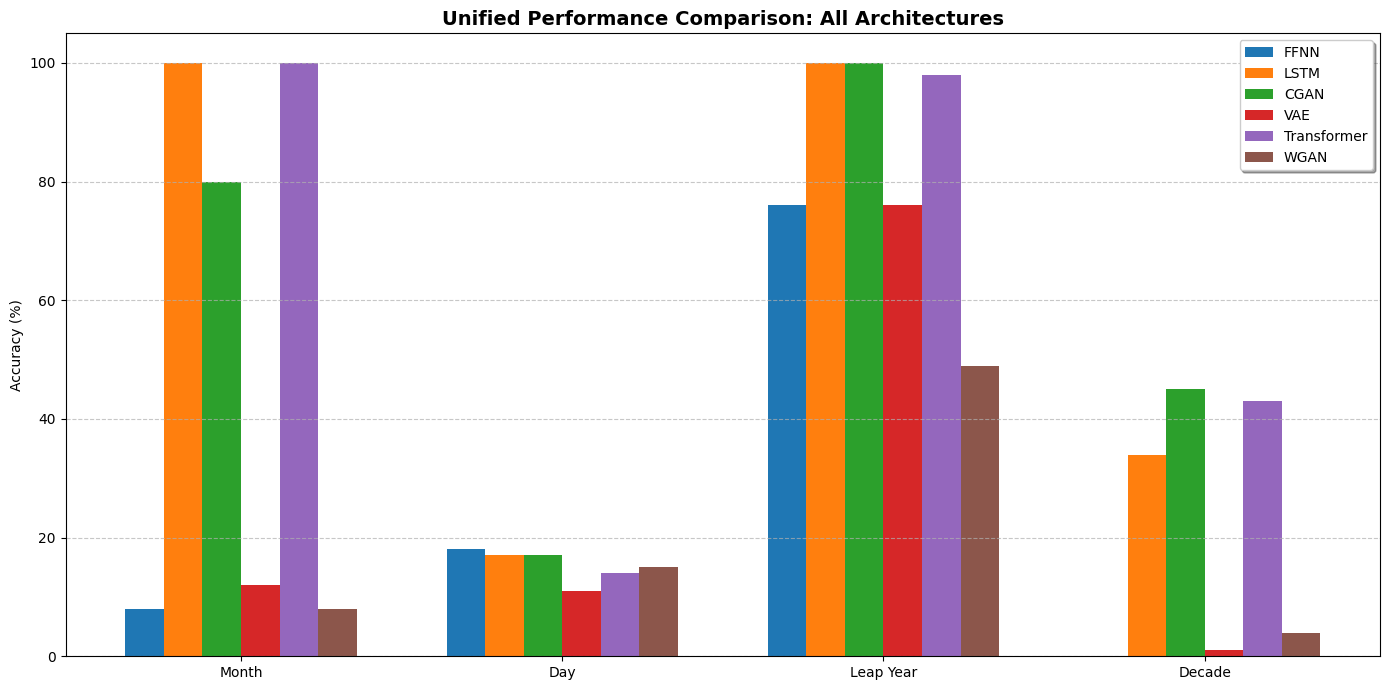

In [106]:
import numpy as np

# Consolidated Accuracy Comparison for all 6 Models
metrics = ['Month', 'Day', 'Leap Year', 'Decade']
all_models = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
x = np.arange(len(metrics))
width = 0.12

fig, ax = plt.subplots(figsize=(14, 7))
for i, model_name in enumerate(all_models):
    ax.bar(x + i*width, final_scores[model_name], width, label=model_name)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Unified Performance Comparison: All Architectures', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/unified_component_accuracy.png', dpi=150)
plt.show()

In [91]:
import pandas as pd
from IPython.display import display

# Prepare the data for the summary table using the existing scores
accuracy_summary_data = []
for model_name in ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']:
    scores = final_scores[model_name]
    accuracy_summary_data.append({
        'Model': model_name,
        'Month Acc (%)': f"{scores[0]:.1f}%",
        'Day Acc (%)': f"{scores[1]:.1f}%",
        'Leap Year Acc (%)': f"{scores[2]:.1f}%",
        'Decade Acc (%)': f"{scores[3]:.1f}%"
    })

# Create and display the DataFrame
df_final_summary = pd.DataFrame(accuracy_summary_data)
print("FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)")
display(df_final_summary)

FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)


,Model,Month Acc (%),Day Acc (%),Leap Year Acc (%),Decade Acc (%)
0,FFNN,8.0%,18.0%,76.0%,0.0%
1,LSTM,100.0%,17.0%,100.0%,34.0%
2,CGAN,80.0%,17.0%,100.0%,45.0%
3,VAE,12.0%,11.0%,76.0%,1.0%
4,Transformer,100.0%,14.0%,98.0%,43.0%
5,WGAN,8.0%,15.0%,49.0%,4.0%


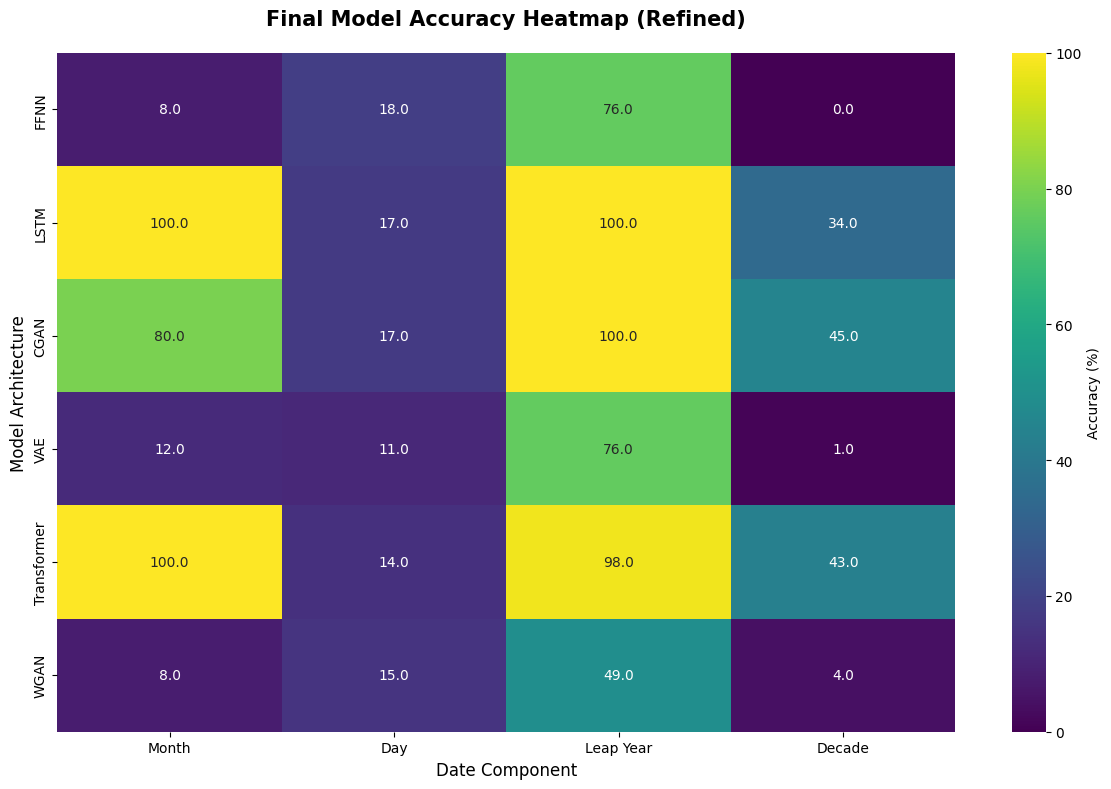

In [101]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Refresh the heatmap data
models_list = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
components = ['Month', 'Day', 'Leap Year', 'Decade']
heatmap_data = [final_scores[m] for m in models_list]

df_heatmap = pd.DataFrame(heatmap_data, index=models_list, columns=components)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'Accuracy (%)'})

plt.title('Final Model Accuracy Heatmap (Refined)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Date Component', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/updated_accuracy_heatmap.png', dpi=150)
plt.show()